<a href="https://colab.research.google.com/github/divya-mallapally/Data-science-project-on-Customer-Segmentation-using-K-means/blob/main/Customer_Segmentation_using_K_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = {
    "Customer_ID": range(1, 21),
    "Age": [
        22,25,28,32,35,40,45,50,23,27,
        31,36,42,48,52,26,30,38,44,55
    ],
    "Gender": [
        "Female","Male","Female","Male","Female",
        "Male","Female","Male","Female","Male",
        "Female","Male","Female","Male","Female",
        "Male","Female","Male","Female","Male"
    ],
    "Annual_Income": [
        25000,30000,28000,45000,50000,
        60000,75000,80000,27000,35000,
        42000,55000,70000,85000,90000,
        32000,48000,65000,78000,95000
    ],
    "Spending_Score": [
        85,70,90,60,75,
        40,80,35,88,65,
        55,45,78,30,25,
        72,68,50,82,20
    ],
    "Purchase_Frequency": [
        15,12,18,9,14,
        6,16,5,17,11,
        8,7,13,4,3,
        12,10,7,14,2
    ]
}

customer_df = pd.DataFrame(data)

customer_df.to_csv(
    "customer_dataset.csv",
    index=False
)

customer_df.head()

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Frequency
0,1,22,Female,25000,85,15
1,2,25,Male,30000,70,12
2,3,28,Female,28000,90,18
3,4,32,Male,45000,60,9
4,5,35,Female,50000,75,14


In [3]:
df = pd.read_csv("customer_dataset.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Frequency
0,1,22,Female,25000,85,15
1,2,25,Male,30000,70,12
2,3,28,Female,28000,90,18
3,4,32,Male,45000,60,9
4,5,35,Female,50000,75,14


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 20
Columns: 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Customer_ID         20 non-null     int64 
 1   Age                 20 non-null     int64 
 2   Gender              20 non-null     object
 3   Annual_Income       20 non-null     int64 
 4   Spending_Score      20 non-null     int64 
 5   Purchase_Frequency  20 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 1.1+ KB


In [5]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Annual_Income,0
Spending_Score,0
Purchase_Frequency,0


In [6]:
df = df.dropna()
df = df.drop_duplicates()

print("Cleaning completed!")
print("Rows remaining:", len(df))

Cleaning completed!
Rows remaining: 20


In [7]:
# for k means
features = [
    "Age",
    "Annual_Income",
    "Spending_Score",
    "Purchase_Frequency"
]

X = df[features]

X.head()

,Age,Annual_Income,Spending_Score,Purchase_Frequency
0,22,25000,85,15
1,25,30000,70,12
2,28,28000,90,18
3,32,45000,60,9
4,35,50000,75,14


In [8]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed!")

Feature scaling completed!


In [9]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

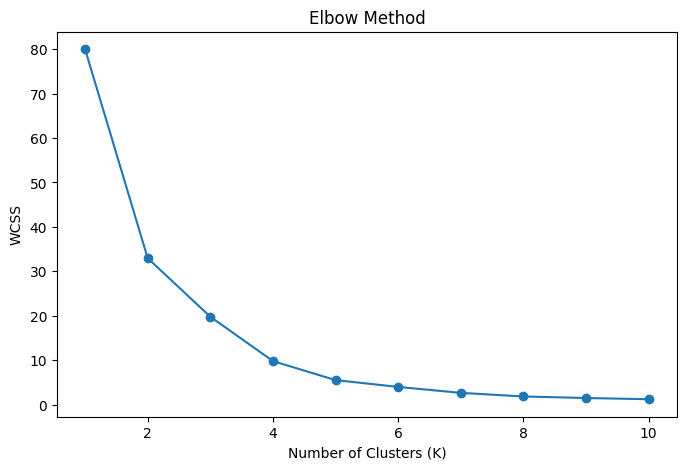

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [11]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Purchase_Frequency,Cluster
0,1,22,Female,25000,85,15,2
1,2,25,Male,30000,70,12,2
2,3,28,Female,28000,90,18,2
3,4,32,Male,45000,60,9,1
4,5,35,Female,50000,75,14,3


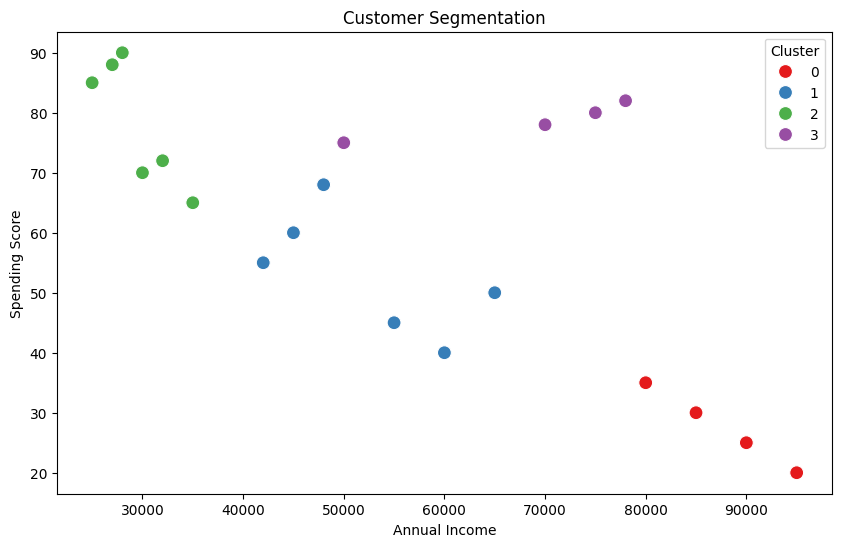

In [12]:
# Visualize
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

In [13]:
cluster_summary = df.groupby("Cluster")[
    ["Age", "Annual_Income", "Spending_Score", "Purchase_Frequency"]
].mean()

cluster_summary

,Age,Annual_Income,Spending_Score,Purchase_Frequency
Cluster,,,,
0,51.250000,87500.0,27.500000,3.500000
1,34.500000,52500.0,53.000000,7.833333
2,25.166667,29500.0,78.333333,14.166667
3,41.500000,68250.0,78.750000,14.250000


In [14]:
df.to_csv(
    "customer_segmented.csv",
    index=False
)

print("Segmented dataset saved!")

Segmented dataset saved!


In [15]:
from google.colab import files

files.download("customer_segmented.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>